# U-Net Training for Nephrocyte Segmentation

This notebook trains a U-Net model to segment nephrocyte images with 3 classes:
- **Background (0)**: Non-annotated regions
- **Slit Membrane (1)**: From `_mem` masks
- **Clusters (2)**: From `_clusters` masks

Regions marked with value 255 in `_ignore` masks are excluded from loss calculation.

In [1]:
"""
Cell 1: Imports and Setup
"""
import os
import warnings
from pathlib import Path
from typing import Tuple, List, Dict, Optional
from datetime import datetime
import json

import numpy as np
import matplotlib.pyplot as plt

# Suppress tifffile warnings about non-standard TIFF tags
warnings.filterwarnings('ignore', message='.*read_bytes.*')
warnings.filterwarnings('ignore', module='tifffile')

from tifffile import imread

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("Imports completed successfully")
print(f"PyTorch version: {torch.__version__}")

Imports completed successfully
PyTorch version: 2.5.1


In [2]:
"""
Cell 2: Device Configuration (MPS for Apple Silicon)
"""

def get_device() -> torch.device:
    """
    Detect and configure the best available device.
    Priority: MPS (Apple Silicon) > CUDA > CPU
    """
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using MPS (Apple Silicon GPU)")
        print(f"MPS built: {torch.backends.mps.is_built()}")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("Using CPU (no GPU acceleration available)")
    
    return device

DEVICE = get_device()
print(f"\nDevice selected: {DEVICE}")

Using MPS (Apple Silicon GPU)
MPS built: True

Device selected: mps


In [3]:
"""
Cell 3: Dataset Validation
Finds all images and verifies matching masks exist.
"""
' /Volumes/SanDisk1Tb/00_Code_Experiments/Code056_sanja_nephrocytes_dataset_to_train_unet/datasets_2/train_set/train_images'
# Define paths
BASE_DIR = Path("/Volumes/SanDisk1Tb/00_Code_Experiments/Code056_sanja_nephrocytes_dataset_to_train_unet")
TRAIN_IMG_DIR = BASE_DIR / "datasets_2/train_set/train_images"
TRAIN_MASK_DIR = BASE_DIR / "datasets_2/train_set/train_masks"
TEST_IMG_DIR = BASE_DIR / "datasets_2/test_set/test_images"
TEST_MASK_DIR = BASE_DIR / "datasets_2/test_set/test_masks"


def find_mask_file(mask_dir: Path, base_name: str, suffix: str) -> Optional[Path]:
    """
    Find mask file with given suffix, checking both .tif and .tiff extensions.
    """
    for ext in ['.tif', '.tiff']:
        mask_path = mask_dir / f"{base_name}{suffix}{ext}"
        if mask_path.exists():
            return mask_path
    return None


def validate_dataset(img_dir: Path, mask_dir: Path, dataset_name: str) -> List[Dict]:
    """
    Validate dataset: find images and verify all three masks exist.
    Returns list of valid samples with paths.
    """
    valid_samples = []
    missing_masks = []
    
    # Get all image files (exclude macOS metadata files starting with ._)
    image_files = sorted([
        f for f in img_dir.glob("*.tif") 
        if not f.name.startswith('._')
    ])
    
    print(f"\n{'='*60}")
    print(f"Validating {dataset_name}")
    print(f"{'='*60}")
    print(f"Image directory: {img_dir}")
    print(f"Mask directory: {mask_dir}")
    print(f"Total image files found: {len(image_files)}")
    
    for img_path in image_files:
        # Extract base name (without extension)
        base_name = img_path.stem
        
        # Find all three masks
        mem_mask = find_mask_file(mask_dir, base_name, "_mem")
        clusters_mask = find_mask_file(mask_dir, base_name, "_clusters")
        ignore_mask = find_mask_file(mask_dir, base_name, "_ignore")
        
        if all([mem_mask, clusters_mask, ignore_mask]):
            valid_samples.append({
                'image': img_path,
                'mem_mask': mem_mask,
                'clusters_mask': clusters_mask,
                'ignore_mask': ignore_mask,
                'base_name': base_name
            })
        else:
            missing = []
            if not mem_mask: missing.append("mem")
            if not clusters_mask: missing.append("clusters")
            if not ignore_mask: missing.append("ignore")
            missing_masks.append((base_name, missing))
    
    print(f"Valid samples (all masks found): {len(valid_samples)}")
    
    if missing_masks:
        print(f"\nWARNING: {len(missing_masks)} images with missing masks:")
        for name, missing in missing_masks[:5]:
            print(f"  - {name}: missing {missing}")
        if len(missing_masks) > 5:
            print(f"  ... and {len(missing_masks) - 5} more")
    
    return valid_samples


# Validate both datasets
train_samples = validate_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, "Training Set")
test_samples = validate_dataset(TEST_IMG_DIR, TEST_MASK_DIR, "Test Set")

# Quick sanity check - load one sample
if train_samples:
    sample = train_samples[0]
    img = imread(sample['image'])
    mem = imread(sample['mem_mask'])
    clusters = imread(sample['clusters_mask'])
    ignore = imread(sample['ignore_mask'])
    
    print(f"\n{'='*60}")
    print("Sample Data Check")
    print(f"{'='*60}")
    print(f"Sample: {sample['base_name']}")
    print(f"Image: shape={img.shape}, dtype={img.dtype}, range=[{img.min()}, {img.max()}]")
    print(f"Membrane mask: unique values={np.unique(mem)}")
    print(f"Clusters mask: unique values={np.unique(clusters)}")
    print(f"Ignore mask: unique values={np.unique(ignore)}")


Validating Training Set
Image directory: /Volumes/SanDisk1Tb/00_Code_Experiments/Code056_sanja_nephrocytes_dataset_to_train_unet/datasets_2/train_set/train_images
Mask directory: /Volumes/SanDisk1Tb/00_Code_Experiments/Code056_sanja_nephrocytes_dataset_to_train_unet/datasets_2/train_set/train_masks
Total image files found: 189
Valid samples (all masks found): 189

Validating Test Set
Image directory: /Volumes/SanDisk1Tb/00_Code_Experiments/Code056_sanja_nephrocytes_dataset_to_train_unet/datasets_2/test_set/test_images
Mask directory: /Volumes/SanDisk1Tb/00_Code_Experiments/Code056_sanja_nephrocytes_dataset_to_train_unet/datasets_2/test_set/test_masks
Total image files found: 16
Valid samples (all masks found): 16

Sample Data Check
Sample: A14-tile02-blur
Image: shape=(300, 300), dtype=uint8, range=[0, 141]
Membrane mask: unique values=[0 1]
Clusters mask: unique values=[0]
Ignore mask: unique values=[0]


In [4]:
"""
Cell 4: Training Parameters
All hyperparameters grouped here for easy modification.
"""

# =============================================================================
# DATA PARAMETERS
# =============================================================================
NUM_CLASSES = 3          # background=0, membrane=1, clusters=2
IGNORE_INDEX = 255       # Pixels with this label are ignored in loss
CROP_SIZE = (250, 250)   # Random crop size for training (matches smallest image)

# =============================================================================
# MODEL PARAMETERS
# =============================================================================
ENCODER_CHANNELS = [64, 128, 256, 512]  # Encoder channel progression
BOTTLENECK_CHANNELS = 1024               # Bottleneck (deepest) channels
USE_BATCH_NORM = True                    # Use BatchNorm in conv blocks
DROPOUT_RATE = 0.1                       # Dropout rate (0.0 = no dropout)

# =============================================================================
# TRAINING PARAMETERS
# =============================================================================
BATCH_SIZE = 2           # Batch size (adjust based on GPU memory)
NUM_EPOCHS = 200         # Total training epochs
LEARNING_RATE = 1e-4     # Initial learning rate
WEIGHT_DECAY = 5e-5      # L2 regularization

# Learning rate scheduler
USE_LR_SCHEDULER = True
LR_PATIENCE = 10         # Epochs to wait before reducing LR
LR_FACTOR = 0.5          # Factor to reduce LR by

# Early stopping (optional)
USE_EARLY_STOPPING = True
EARLY_STOP_PATIENCE = 25

# =============================================================================
# OUTPUT SETTINGS
# =============================================================================
OUTPUT_DIR = BASE_DIR / "training_output"
SAVE_MODEL = True
SAVE_BEST_ONLY = True    # Only save model with best validation loss
REPORT_FILE = "training_report.txt"

# =============================================================================
# DISPLAY PARAMETERS
# =============================================================================
PRINT_EVERY = 1          # Print metrics every N epochs

print("Training Parameters Summary")
print("="*60)
print(f"Classes: {NUM_CLASSES} (background, membrane, clusters)")
print(f"Ignore index: {IGNORE_INDEX}")
print(f"Crop size: {CROP_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"LR scheduler: {USE_LR_SCHEDULER} (patience={LR_PATIENCE}, factor={LR_FACTOR})")
print(f"Early stopping: {USE_EARLY_STOPPING}")
print(f"Device: {DEVICE}")
print(f"Encoder channels: {ENCODER_CHANNELS}")
print(f"Bottleneck channels: {BOTTLENECK_CHANNELS}")
print(f"Output directory: {OUTPUT_DIR}")
print("="*60)

Training Parameters Summary
Classes: 3 (background, membrane, clusters)
Ignore index: 255
Crop size: (250, 250)
Batch size: 2
Epochs: 200
Learning rate: 0.0001
Weight decay: 5e-05
LR scheduler: True (patience=10, factor=0.5)
Early stopping: True
Device: mps
Encoder channels: [64, 128, 256, 512]
Bottleneck channels: 1024
Output directory: /Volumes/SanDisk1Tb/00_Code_Experiments/Code056_sanja_nephrocytes_dataset_to_train_unet/training_output


In [5]:
"""
Cell 5: Dataset Class and Data Loading
Handles mask merging and random/center cropping for consistent batch sizes.
"""

def pad_to_multiple(tensor: torch.Tensor, multiple: int = 16) -> Tuple[torch.Tensor, Tuple[int, int, int, int]]:
    """
    Pad tensor so spatial dimensions are divisible by `multiple`.
    Returns padded tensor and padding amounts (left, right, top, bottom).
    """
    if tensor.dim() == 3:
        _, h, w = tensor.shape
    else:
        h, w = tensor.shape
    
    # Calculate required padding
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    
    # Distribute padding evenly (prefer padding on right/bottom if odd)
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    
    # F.pad format: (left, right, top, bottom)
    padding = (pad_left, pad_right, pad_top, pad_bottom)
    
    if any(p > 0 for p in padding):
        tensor = F.pad(tensor, padding, mode='reflect')
    
    return tensor, padding


class NephrocyteDataset(Dataset):
    """
    Dataset for nephrocyte segmentation.
    Loads images and merges three separate masks into one combined mask.
    Uses random cropping for training and center cropping for validation/test.
    """
    
    def __init__(
        self, 
        samples: List[Dict], 
        crop_size: Tuple[int, int] = (250, 250),
        is_training: bool = True,
        pad_multiple: int = 16
    ):
        """
        Args:
            samples: List of dicts with image and mask paths
            crop_size: Size of crops (height, width)
            is_training: If True, use random crops; if False, use center crops
            pad_multiple: Pad images to be divisible by this value
        """
        self.samples = samples
        self.crop_size = crop_size
        self.is_training = is_training
        self.pad_multiple = pad_multiple
        
    def __len__(self) -> int:
        return len(self.samples)
    
    def merge_masks(
        self, 
        mem_mask: np.ndarray, 
        clusters_mask: np.ndarray, 
        ignore_mask: np.ndarray
    ) -> np.ndarray:
        """
        Merge three separate masks into one combined mask.
        
        Values:
        - 0: Background
        - 1: Membrane (from _mem mask)
        - 2: Clusters (from _clusters mask)
        - 255: Ignore (from _ignore mask, overrides all)
        """
        # Start with background (zeros)
        combined = np.zeros_like(mem_mask, dtype=np.uint8)
        
        # Add membrane (value 1)
        combined[mem_mask == 1] = 1
        
        # Add clusters (value 2)
        combined[clusters_mask == 2] = 2
        
        # Apply ignore mask last (value 255 overrides everything)
        combined[ignore_mask == 255] = 255
        
        # Also treat cluster mask value 255 as ignore (some masks use this)
        combined[clusters_mask == 255] = 255
        
        return combined
    
    def random_crop(
        self, 
        image: np.ndarray, 
        mask: np.ndarray
    ) -> Tuple[np.ndarray, np.ndarray, Tuple[int, int]]:
        """
        Apply random crop to image and mask.
        Returns cropped arrays and crop position (top, left).
        """
        h, w = image.shape
        crop_h, crop_w = self.crop_size
        
        # Random top-left corner
        top = np.random.randint(0, h - crop_h + 1)
        left = np.random.randint(0, w - crop_w + 1)
        
        image_crop = image[top:top+crop_h, left:left+crop_w]
        mask_crop = mask[top:top+crop_h, left:left+crop_w]
        
        return image_crop, mask_crop, (top, left)
    
    def center_crop(
        self, 
        image: np.ndarray, 
        mask: np.ndarray
    ) -> Tuple[np.ndarray, np.ndarray, Tuple[int, int]]:
        """
        Apply center crop to image and mask.
        Returns cropped arrays and crop position (top, left).
        """
        h, w = image.shape
        crop_h, crop_w = self.crop_size
        
        # Center position
        top = (h - crop_h) // 2
        left = (w - crop_w) // 2
        
        image_crop = image[top:top+crop_h, left:left+crop_w]
        mask_crop = mask[top:top+crop_h, left:left+crop_w]
        
        return image_crop, mask_crop, (top, left)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, Dict]:
        """
        Load and preprocess a sample.
        
        Returns:
            image: Tensor of shape (1, H, W) - normalized to [0, 1]
            mask: Tensor of shape (H, W) - class labels (0, 1, 2, or 255)
            meta: Dictionary with metadata (crop info, original shape, etc.)
        """
        sample = self.samples[idx]
        
        # Load image and masks
        image = imread(sample['image']).astype(np.float32)
        mem_mask = imread(sample['mem_mask'])
        clusters_mask = imread(sample['clusters_mask'])
        ignore_mask = imread(sample['ignore_mask'])
        
        # Store original shape
        orig_shape = image.shape
        
        # Merge masks
        mask = self.merge_masks(mem_mask, clusters_mask, ignore_mask)
        
        # Normalize image to [0, 1]
        if image.max() > 0:
            image = image / 255.0
        
        # Apply cropping
        if self.is_training:
            image, mask, crop_pos = self.random_crop(image, mask)
        else:
            image, mask, crop_pos = self.center_crop(image, mask)
        
        # Convert to tensors
        image = torch.from_numpy(image).unsqueeze(0)  # Add channel dim: (1, H, W)
        mask = torch.from_numpy(mask.copy()).long()  # (H, W)
        
        # Pad to multiple of 16 for U-Net (if crop size is not already divisible)
        image, padding = pad_to_multiple(image, self.pad_multiple)
        mask = mask.unsqueeze(0)  # Add dim for padding
        mask, _ = pad_to_multiple(mask, self.pad_multiple)
        mask = mask.squeeze(0)  # Remove added dim
        
        meta = {
            'base_name': sample['base_name'],
            'orig_shape': orig_shape,
            'crop_pos': crop_pos,
            'padding': padding
        }
        
        return image, mask, meta


def create_dataloaders(
    train_samples: List[Dict],
    test_samples: List[Dict],
    batch_size: int,
    crop_size: Tuple[int, int] = (250, 250),
    pad_multiple: int = 16
) -> Tuple[DataLoader, DataLoader]:
    """
    Create training and test DataLoaders.
    Training uses random crops, test uses center crops.
    """
    train_dataset = NephrocyteDataset(
        train_samples, 
        crop_size=crop_size,
        is_training=True,  # Random crops
        pad_multiple=pad_multiple
    )
    test_dataset = NephrocyteDataset(
        test_samples, 
        crop_size=crop_size,
        is_training=False,  # Center crops
        pad_multiple=pad_multiple
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,  # MPS works best with num_workers=0
        pin_memory=False  # Not needed for MPS
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )
    
    return train_loader, test_loader


# Create DataLoaders
train_loader, test_loader = create_dataloaders(
    train_samples, 
    test_samples, 
    BATCH_SIZE,
    crop_size=CROP_SIZE,
    pad_multiple=16
)

print(f"Training samples: {len(train_samples)}")
print(f"Test samples: {len(test_samples)}")
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Crop size: {CROP_SIZE}")

# Verify a batch
sample_batch = next(iter(train_loader))
images, masks, metas = sample_batch
print(f"\nBatch shapes:")
print(f"  Images: {images.shape}")
print(f"  Masks: {masks.shape}")
print(f"  Unique mask values: {torch.unique(masks).tolist()}")

Training samples: 189
Test samples: 16
Training batches: 95
Test batches: 8
Crop size: (250, 250)

Batch shapes:
  Images: torch.Size([2, 1, 256, 256])
  Masks: torch.Size([2, 256, 256])
  Unique mask values: [0, 1]


In [6]:
"""
Cell 6: U-Net Model Architecture
"""

class ConvBlock(nn.Module):
    """
    Double convolution block: Conv -> BN -> ReLU -> Conv -> BN -> ReLU
    """
    def __init__(
        self, 
        in_channels: int, 
        out_channels: int, 
        use_batch_norm: bool = True,
        dropout_rate: float = 0.0
    ):
        super().__init__()
        
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_batch_norm),
        ]
        if use_batch_norm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
        
        layers.append(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not use_batch_norm)
        )
        if use_batch_norm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
        
        if dropout_rate > 0:
            layers.append(nn.Dropout2d(dropout_rate))
        
        self.block = nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class EncoderBlock(nn.Module):
    """
    Encoder block: ConvBlock -> MaxPool
    """
    def __init__(
        self, 
        in_channels: int, 
        out_channels: int,
        use_batch_norm: bool = True,
        dropout_rate: float = 0.0
    ):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels, use_batch_norm, dropout_rate)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            pooled: Downsampled features for next encoder block
            skip: Features before pooling for skip connection
        """
        skip = self.conv(x)
        pooled = self.pool(skip)
        return pooled, skip


class DecoderBlock(nn.Module):
    """
    Decoder block: Upsample -> Concat skip -> ConvBlock
    """
    def __init__(
        self, 
        in_channels: int, 
        skip_channels: int,
        out_channels: int,
        use_batch_norm: bool = True,
        dropout_rate: float = 0.0
    ):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(
            in_channels, in_channels // 2, 
            kernel_size=2, stride=2
        )
        self.conv = ConvBlock(
            in_channels // 2 + skip_channels, 
            out_channels, 
            use_batch_norm, 
            dropout_rate
        )
    
    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.upsample(x)
        
        # Handle size mismatch due to odd dimensions
        diff_h = skip.size(2) - x.size(2)
        diff_w = skip.size(3) - x.size(3)
        x = F.pad(x, [diff_w // 2, diff_w - diff_w // 2,
                      diff_h // 2, diff_h - diff_h // 2])
        
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """
    U-Net architecture for semantic segmentation.
    
    Architecture:
        Input -> Encoder (4 blocks) -> Bottleneck -> Decoder (4 blocks) -> Output
    """
    
    def __init__(
        self,
        in_channels: int = 1,
        num_classes: int = 3,
        encoder_channels: List[int] = [64, 128, 256, 512],
        bottleneck_channels: int = 1024,
        use_batch_norm: bool = True,
        dropout_rate: float = 0.0
    ):
        super().__init__()
        
        self.in_channels = in_channels
        self.num_classes = num_classes
        
        # Encoder
        self.encoders = nn.ModuleList()
        ch_in = in_channels
        for ch_out in encoder_channels:
            self.encoders.append(
                EncoderBlock(ch_in, ch_out, use_batch_norm, dropout_rate)
            )
            ch_in = ch_out
        
        # Bottleneck
        self.bottleneck = ConvBlock(
            encoder_channels[-1], bottleneck_channels, 
            use_batch_norm, dropout_rate
        )
        
        # Decoder
        self.decoders = nn.ModuleList()
        decoder_channels = encoder_channels[::-1]  # Reverse order
        ch_in = bottleneck_channels
        for i, ch_out in enumerate(decoder_channels):
            skip_ch = decoder_channels[i]  # Skip connection channels
            self.decoders.append(
                DecoderBlock(ch_in, skip_ch, ch_out, use_batch_norm, dropout_rate)
            )
            ch_in = ch_out
        
        # Output
        self.output = nn.Conv2d(encoder_channels[0], num_classes, kernel_size=1)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights using Kaiming initialization."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder path
        skips = []
        for encoder in self.encoders:
            x, skip = encoder(x)
            skips.append(skip)
        
        # Bottleneck
        x = self.bottleneck(x)
        
        # Decoder path
        skips = skips[::-1]  # Reverse for decoder
        for decoder, skip in zip(self.decoders, skips):
            x = decoder(x, skip)
        
        # Output
        return self.output(x)


# Create model
model = UNet(
    in_channels=1,
    num_classes=NUM_CLASSES,
    encoder_channels=ENCODER_CHANNELS,
    bottleneck_channels=BOTTLENECK_CHANNELS,
    use_batch_norm=USE_BATCH_NORM,
    dropout_rate=DROPOUT_RATE
).to(DEVICE)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("Model: U-Net")
print(f"Input channels: 1 (grayscale)")
print(f"Output classes: {NUM_CLASSES}")
print(f"Encoder channels: {ENCODER_CHANNELS}")
print(f"Bottleneck channels: {BOTTLENECK_CHANNELS}")
print(f"Batch normalization: {USE_BATCH_NORM}")
print(f"Dropout rate: {DROPOUT_RATE}")
print(f"Total parameters: {count_parameters(model):,}")
print(f"Device: {DEVICE}")

# Test forward pass
with torch.no_grad():
    test_input = images[:1].to(DEVICE)
    test_output = model(test_input)
    print(f"\nTest forward pass:")
    print(f"  Input shape: {test_input.shape}")
    print(f"  Output shape: {test_output.shape}")

Model: U-Net
Input channels: 1 (grayscale)
Output classes: 3
Encoder channels: [64, 128, 256, 512]
Bottleneck channels: 1024
Batch normalization: True
Dropout rate: 0.1
Total parameters: 31,036,611
Device: mps

Test forward pass:
  Input shape: torch.Size([1, 1, 256, 256])
  Output shape: torch.Size([1, 3, 256, 256])


In [7]:
"""
Cell 7: Training Loop with Metrics Tracking
"""

def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
) -> float:
    """
    Train for one epoch.
    Returns average loss.
    """
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for images, masks, _ in loader:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> float:
    """
    Evaluate model on a dataset.
    Returns average loss.
    """
    model.eval()
    total_loss = 0.0
    num_batches = 0
    
    for images, masks, _ in loader:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    num_epochs: int,
    learning_rate: float,
    weight_decay: float,
    device: torch.device
) -> Dict:
    """
    Full training loop with metrics tracking.
    
    Returns:
        Dictionary with training history and best model state
    """
    # Loss function with ignore_index for pixels labeled 255
    criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
    
    # Optimizer
    optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # Learning rate scheduler
    scheduler = None
    if USE_LR_SCHEDULER:
        scheduler = ReduceLROnPlateau(
            optimizer, mode='min', factor=LR_FACTOR, 
            patience=LR_PATIENCE, verbose=True
        )
    
    # History tracking
    history = {
        'train_loss': [],
        'test_loss': [],
        'learning_rate': [],
        'best_epoch': 0,
        'best_test_loss': float('inf')
    }
    
    best_model_state = None
    epochs_without_improvement = 0
    
    # Training start time
    start_time = datetime.now()
    print(f"\n{'='*70}")
    print(f"Training Started: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*70}\n")
    
    for epoch in range(1, num_epochs + 1):
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate
        test_loss = evaluate(model, test_loader, criterion, device)
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        # Update history
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['learning_rate'].append(current_lr)
        
        # Update scheduler
        if scheduler is not None:
            scheduler.step(test_loss)
        
        # Check for best model
        if test_loss < history['best_test_loss']:
            history['best_test_loss'] = test_loss
            history['best_epoch'] = epoch
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        
        # Print progress
        if epoch % PRINT_EVERY == 0:
            print(f"Epoch {epoch:3d}/{num_epochs} | "
                  f"Train Loss: {train_loss:.6f} | "
                  f"Test Loss: {test_loss:.6f} | "
                  f"LR: {current_lr:.2e} | "
                  f"Best: {history['best_test_loss']:.6f} (ep {history['best_epoch']})")
        
        # Early stopping check
        if USE_EARLY_STOPPING and epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping triggered after {epoch} epochs")
            break
    
    # Training end time
    end_time = datetime.now()
    duration = end_time - start_time
    
    print(f"\n{'='*70}")
    print(f"Training Completed: {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Total Duration: {duration}")
    print(f"Best Test Loss: {history['best_test_loss']:.6f} at epoch {history['best_epoch']}")
    print(f"{'='*70}")
    
    # Store additional info
    history['start_time'] = start_time.isoformat()
    history['end_time'] = end_time.isoformat()
    history['duration_seconds'] = duration.total_seconds()
    history['best_model_state'] = best_model_state
    
    return history


# Run training
history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    device=DEVICE
)

/Users/pavel/miniconda3/envs/unet_gpu/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Training Started: 2026-01-20 10:57:15

Epoch   1/200 | Train Loss: 1.247490 | Test Loss: 1.093663 | LR: 1.00e-04 | Best: 1.093663 (ep 1)
Epoch   2/200 | Train Loss: 0.653848 | Test Loss: 0.987044 | LR: 1.00e-04 | Best: 0.987044 (ep 2)
Epoch   3/200 | Train Loss: 0.577662 | Test Loss: 5.419867 | LR: 1.00e-04 | Best: 0.987044 (ep 2)
Epoch   4/200 | Train Loss: 0.497123 | Test Loss: 0.905385 | LR: 1.00e-04 | Best: 0.905385 (ep 4)
Epoch   5/200 | Train Loss: 0.480663 | Test Loss: 0.618146 | LR: 1.00e-04 | Best: 0.618146 (ep 5)
Epoch   6/200 | Train Loss: 0.461171 | Test Loss: 0.544930 | LR: 1.00e-04 | Best: 0.544930 (ep 6)
Epoch   7/200 | Train Loss: 0.436112 | Test Loss: 0.932196 | LR: 1.00e-04 | Best: 0.544930 (ep 6)
Epoch   8/200 | Train Loss: 0.408293 | Test Loss: 0.544594 | LR: 1.00e-04 | Best: 0.544594 (ep 8)
Epoch   9/200 | Train Loss: 0.409988 | Test Loss: 0.537817 | LR: 1.00e-04 | Best: 0.537817 (ep 9)
Epoch  10/200 | Train Loss: 0.404265 | Test Loss: 0.525723 | LR: 1.00e-04 | Be

Plot saved to: /Volumes/SanDisk1Tb/00_Code_Experiments/Code056_sanja_nephrocytes_dataset_to_train_unet/training_output/training_curves.png


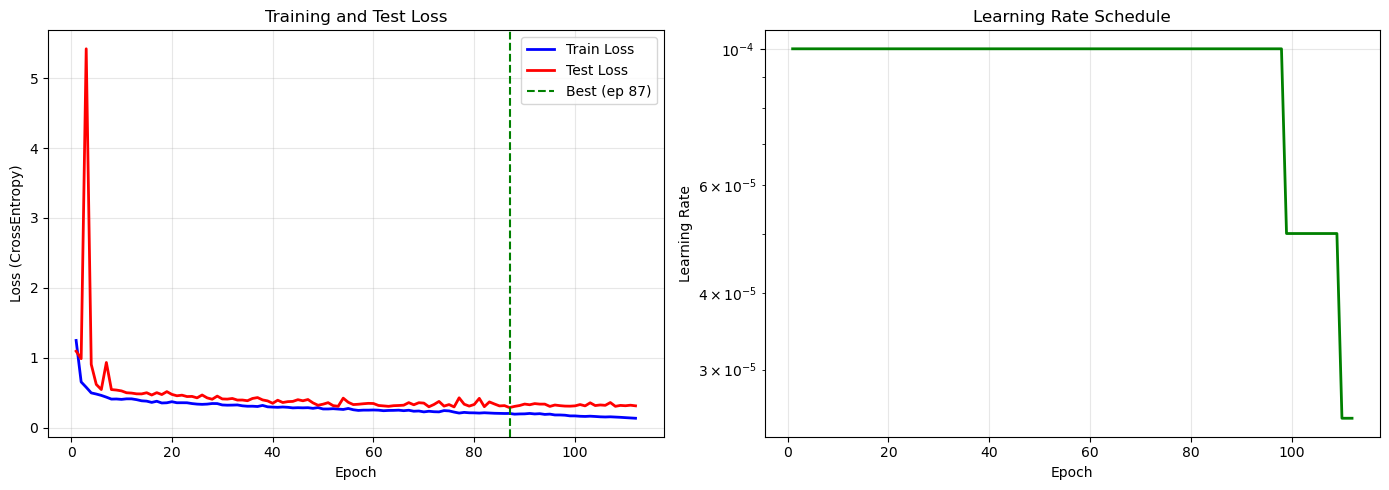

Loaded best model from epoch 87
Predictions saved to: /Volumes/SanDisk1Tb/00_Code_Experiments/Code056_sanja_nephrocytes_dataset_to_train_unet/training_output/predictions.png


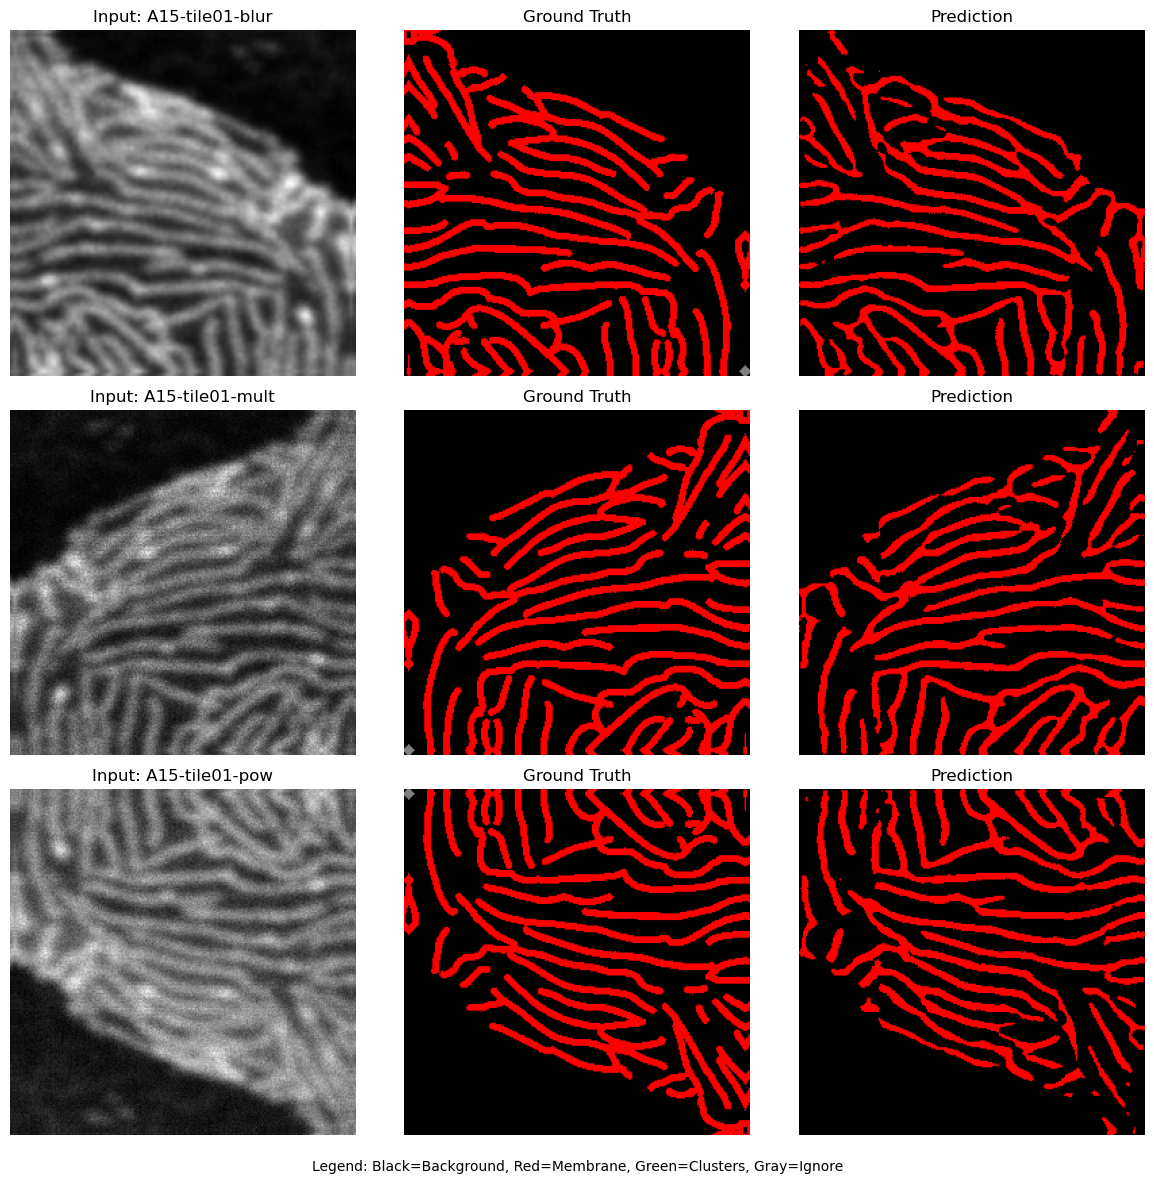

In [8]:
"""
Cell 8: Metrics Visualization
"""

def plot_training_history(history: Dict, save_path: Optional[Path] = None):
    """
    Plot training and test loss over epochs.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss plot
    ax1 = axes[0]
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, history['test_loss'], 'r-', label='Test Loss', linewidth=2)
    ax1.axvline(x=history['best_epoch'], color='g', linestyle='--', 
                label=f'Best (ep {history["best_epoch"]})')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (CrossEntropy)')
    ax1.set_title('Training and Test Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Learning rate plot
    ax2 = axes[1]
    ax2.plot(epochs, history['learning_rate'], 'g-', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Learning Rate')
    ax2.set_title('Learning Rate Schedule')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    
    plt.show()


def visualize_predictions(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    num_samples: int = 3,
    save_path: Optional[Path] = None
):
    """
    Visualize model predictions on test samples.
    """
    model.eval()
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    # Color map for segmentation
    colors = np.array([
        [0, 0, 0],       # Background: black
        [255, 0, 0],     # Membrane: red
        [0, 255, 0],     # Clusters: green
    ], dtype=np.uint8)
    
    sample_idx = 0
    for images, masks, metas in loader:
        if sample_idx >= num_samples:
            break
            
        images = images.to(device)
        
        with torch.no_grad():
            outputs = model(images)
            preds = outputs.argmax(dim=1)
        
        for i in range(images.size(0)):
            if sample_idx >= num_samples:
                break
            
            img = images[i, 0].cpu().numpy()
            mask = masks[i].cpu().numpy()
            pred = preds[i].cpu().numpy()
            
            # Convert masks to RGB for visualization
            mask_rgb = colors[np.clip(mask, 0, 2)]
            pred_rgb = colors[np.clip(pred, 0, 2)]
            
            # Mark ignore regions as gray in ground truth
            mask_rgb[mask == 255] = [128, 128, 128]
            
            axes[sample_idx, 0].imshow(img, cmap='gray')
            axes[sample_idx, 0].set_title(f'Input: {metas["base_name"][i]}')
            axes[sample_idx, 0].axis('off')
            
            axes[sample_idx, 1].imshow(mask_rgb)
            axes[sample_idx, 1].set_title('Ground Truth')
            axes[sample_idx, 1].axis('off')
            
            axes[sample_idx, 2].imshow(pred_rgb)
            axes[sample_idx, 2].set_title('Prediction')
            axes[sample_idx, 2].axis('off')
            
            sample_idx += 1
    
    # Add legend
    fig.text(0.5, 0.02, 'Legend: Black=Background, Red=Membrane, Green=Clusters, Gray=Ignore', 
             ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.05)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Predictions saved to: {save_path}")
    
    plt.show()


# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot training history
plot_training_history(history, OUTPUT_DIR / "training_curves.png")

# Load best model for visualization
if history.get('best_model_state') is not None:
    model.load_state_dict(history['best_model_state'])
    model = model.to(DEVICE)
    print(f"Loaded best model from epoch {history['best_epoch']}")

# Visualize predictions
visualize_predictions(model, test_loader, DEVICE, num_samples=3, 
                     save_path=OUTPUT_DIR / "predictions.png")

In [9]:
"""
Cell 9: Final Report Generation and Model Saving
"""

def generate_report(history: Dict, output_dir: Path) -> str:
    """
    Generate a comprehensive training report.
    """
    report_lines = [
        "="*70,
        "U-NET NEPHROCYTE SEGMENTATION - TRAINING REPORT",
        "="*70,
        "",
        "DATASET INFORMATION",
        "-"*40,
        f"Training samples: {len(train_samples)}",
        f"Test samples: {len(test_samples)}",
        f"Number of classes: {NUM_CLASSES} (background, membrane, clusters)",
        f"Ignore label: {IGNORE_INDEX}",
        "",
        "MODEL ARCHITECTURE",
        "-"*40,
        f"Model: U-Net",
        f"Input channels: 1 (grayscale)",
        f"Encoder channels: {ENCODER_CHANNELS}",
        f"Bottleneck channels: {BOTTLENECK_CHANNELS}",
        f"Batch normalization: {USE_BATCH_NORM}",
        f"Dropout rate: {DROPOUT_RATE}",
        f"Total parameters: {count_parameters(model):,}",
        "",
        "TRAINING CONFIGURATION",
        "-"*40,
        f"Device: {DEVICE}",
        f"Batch size: {BATCH_SIZE}",
        f"Initial learning rate: {LEARNING_RATE}",
        f"Weight decay: {WEIGHT_DECAY}",
        f"LR scheduler: {USE_LR_SCHEDULER}",
    ]
    
    if USE_LR_SCHEDULER:
        report_lines.extend([
            f"LR patience: {LR_PATIENCE}",
            f"LR reduction factor: {LR_FACTOR}",
        ])
    
    report_lines.extend([
        f"Early stopping: {USE_EARLY_STOPPING}",
        f"Epochs trained: {len(history['train_loss'])}",
        f"Max epochs: {NUM_EPOCHS}",
        "",
        "RESULTS",
        "-"*40,
        f"Best epoch: {history['best_epoch']}",
        f"Best test loss: {history['best_test_loss']:.6f}",
        f"Final train loss: {history['train_loss'][-1]:.6f}",
        f"Final test loss: {history['test_loss'][-1]:.6f}",
        f"Final learning rate: {history['learning_rate'][-1]:.2e}",
        "",
        "TIMING",
        "-"*40,
        f"Start time: {history.get('start_time', 'N/A')}",
        f"End time: {history.get('end_time', 'N/A')}",
        f"Duration: {history.get('duration_seconds', 0)/60:.2f} minutes",
        "",
        "LOSS HISTORY (Last 10 epochs)",
        "-"*40,
    ])
    
    # Add last 10 epochs of loss history
    start_idx = max(0, len(history['train_loss']) - 10)
    for i in range(start_idx, len(history['train_loss'])):
        epoch = i + 1
        train_l = history['train_loss'][i]
        test_l = history['test_loss'][i]
        report_lines.append(f"Epoch {epoch:3d}: Train={train_l:.6f}, Test={test_l:.6f}")
    
    report_lines.extend([
        "",
        "="*70,
        f"Report generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
        "="*70,
    ])
    
    report = "\n".join(report_lines)
    
    # Save report
    report_path = output_dir / REPORT_FILE
    with open(report_path, 'w') as f:
        f.write(report)
    print(f"Report saved to: {report_path}")
    
    return report


def save_model_and_history(
    model: nn.Module, 
    history: Dict, 
    output_dir: Path,
    save_best_only: bool = True
):
    """
    Save model weights and training history.
    """
    # Save best model
    if history.get('best_model_state') is not None:
        model_path = output_dir / "unet_best.pth"
        torch.save({
            'model_state_dict': history['best_model_state'],
            'epoch': history['best_epoch'],
            'test_loss': history['best_test_loss'],
            'config': {
                'num_classes': NUM_CLASSES,
                'encoder_channels': ENCODER_CHANNELS,
                'bottleneck_channels': BOTTLENECK_CHANNELS,
                'use_batch_norm': USE_BATCH_NORM,
                'dropout_rate': DROPOUT_RATE,
            }
        }, model_path)
        print(f"Best model saved to: {model_path}")
    
    # Save final model (optional)
    if not save_best_only:
        final_model_path = output_dir / "unet_final.pth"
        torch.save({
            'model_state_dict': model.state_dict(),
            'epoch': len(history['train_loss']),
            'test_loss': history['test_loss'][-1],
        }, final_model_path)
        print(f"Final model saved to: {final_model_path}")
    
    # Save history (without model state dict to reduce size)
    history_to_save = {k: v for k, v in history.items() if k != 'best_model_state'}
    history_path = output_dir / "training_history.json"
    with open(history_path, 'w') as f:
        json.dump(history_to_save, f, indent=2)
    print(f"Training history saved to: {history_path}")


# Generate and print report
report = generate_report(history, OUTPUT_DIR)
print(report)

# Save model and history
if SAVE_MODEL:
    save_model_and_history(model, history, OUTPUT_DIR, SAVE_BEST_ONLY)

print(f"\n{'='*70}")
print("TRAINING COMPLETE")
print(f"All outputs saved to: {OUTPUT_DIR}")
print(f"{'='*70}")

Report saved to: /Volumes/SanDisk1Tb/00_Code_Experiments/Code056_sanja_nephrocytes_dataset_to_train_unet/training_output/training_report.txt
U-NET NEPHROCYTE SEGMENTATION - TRAINING REPORT

DATASET INFORMATION
----------------------------------------
Training samples: 189
Test samples: 16
Number of classes: 3 (background, membrane, clusters)
Ignore label: 255

MODEL ARCHITECTURE
----------------------------------------
Model: U-Net
Input channels: 1 (grayscale)
Encoder channels: [64, 128, 256, 512]
Bottleneck channels: 1024
Batch normalization: True
Dropout rate: 0.1
Total parameters: 31,036,611

TRAINING CONFIGURATION
----------------------------------------
Device: mps
Batch size: 2
Initial learning rate: 0.0001
Weight decay: 5e-05
LR scheduler: True
LR patience: 10
LR reduction factor: 0.5
Early stopping: True
Epochs trained: 112
Max epochs: 200

RESULTS
----------------------------------------
Best epoch: 87
Best test loss: 0.286809
Final train loss: 0.134370
Final test loss: 0.311